# Klasifikasi Rimpang — BASELINE
**Preprocessing:** Tidak ada (hanya grayscale untuk GLCM)

---
**Cara pakai file ini sebagai template:**
1. Copy file ini, rename sesuai eksperimen (misal `p1_grayscale.ipynb`)
2. Ganti `EXP_NAME` di Cell 2
3. Ganti isi fungsi `preprocess()` di Cell 3
4. Jalankan semua cell dari atas

In [21]:
# Cell 1 — Import
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from library import (
    load_images, extract_glcm_features, evaluate_and_save, preview_preprocessing,
    manual_resize, manual_bgr_to_grayscale, manual_gaussian_blur,
    manual_median_blur, manual_clahe, manual_histogram_equalization,
    manual_erosion, manual_dilation, manual_opening, manual_closing
)

print('Import berhasil')

Import berhasil


Kode pada Cell 1 berfungsi untuk mengimpor seluruh pustaka dan fungsi yang dibutuhkan dalam proses klasifikasi citra. Library **NumPy** dan **Pandas** digunakan untuk pengolahan data numerik dan tabular, sedangkan **os** digunakan untuk mengakses direktori atau file dataset. Dari pustaka **Scikit-Learn**, diimpor fungsi **train_test_split** untuk membagi data menjadi data latih dan data uji, **LabelEncoder** untuk mengubah label kategori menjadi bentuk numerik, serta tiga algoritma klasifikasi yaitu **K-Nearest Neighbor (KNN)**, **Support Vector Machine (SVM)**, dan **Random Forest**. Selain itu, kode juga mengimpor berbagai fungsi dari file `library.py`, seperti pemuatan citra (`load_images`), ekstraksi fitur tekstur menggunakan **GLCM** (`extract_glcm_features`), evaluasi model (`evaluate_and_save`), serta sejumlah fungsi prapemrosesan citra seperti resize, konversi grayscale, filtering, histogram equalization, CLAHE, dan operasi morfologi. Setelah seluruh modul berhasil dimuat, program menampilkan pesan **"Import berhasil"** sebagai indikator bahwa lingkungan kerja telah siap untuk menjalankan tahapan pemrosesan citra dan klasifikasi berikutnya.

In [22]:
# Cell 2 — Konfigurasi
# ⚠️ GANTI INI sesuai eksperimenmu
EXP_NAME = 'P4_Median_CLAHE'

Cell 2 berfungsi sebagai bagian konfigurasi eksperimen dengan mendefinisikan variabel `EXP_NAME` yang digunakan untuk memberi nama atau identitas pada skenario pengujian yang sedang dijalankan. Nilai `'P4_Median_CLAHE'` menunjukkan bahwa eksperimen ini menerapkan tahapan prapemrosesan berupa **Median Blur** untuk mengurangi noise pada citra dan **CLAHE (Contrast Limited Adaptive Histogram Equalization)** untuk meningkatkan kontras secara adaptif. Nama eksperimen ini nantinya dapat digunakan untuk membedakan hasil evaluasi, penyimpanan model, maupun laporan performa dari eksperimen lain, sehingga memudahkan proses perbandingan dan analisis berbagai kombinasi metode prapemrosesan yang diuji.

In [23]:
# Cell 3 — Fungsi Preprocessing
# ⚠️ GANTI ISI FUNGSI INI sesuai eksperimenmu

def preprocess(img):
    resized = manual_resize(img, 128, 128)
    gray = manual_bgr_to_grayscale(resized)
    blurred = manual_median_blur(gray, 10)
    clahe_img = manual_clahe(blurred)
    return clahe_img

Fungsi `preprocess()` digunakan untuk melakukan serangkaian tahapan prapemrosesan citra sebelum proses ekstraksi fitur dan klasifikasi. Pertama, citra diubah ukurannya menjadi **128×128 piksel** menggunakan `manual_resize()` agar seluruh data memiliki dimensi yang seragam. Selanjutnya, citra berwarna dikonversi menjadi **grayscale** melalui `manual_bgr_to_grayscale()` sehingga informasi intensitas lebih mudah dianalisis dan kompleksitas data berkurang. Setelah itu, diterapkan **Median Blur** dengan ukuran kernel 10 menggunakan `manual_median_blur()` untuk mengurangi noise, khususnya noise tipe salt-and-pepper, tanpa terlalu menghilangkan tepi objek penting. Tahap berikutnya adalah penerapan **CLAHE (Contrast Limited Adaptive Histogram Equalization)** melalui `manual_clahe()`, yang bertujuan meningkatkan kontras citra secara lokal sehingga detail tekstur menjadi lebih jelas. Hasil akhir dari seluruh tahapan tersebut dikembalikan dalam variabel `clahe_img`, yang kemudian digunakan sebagai citra masukan untuk proses ekstraksi fitur dan klasifikasi.

Total gambar loaded: 630


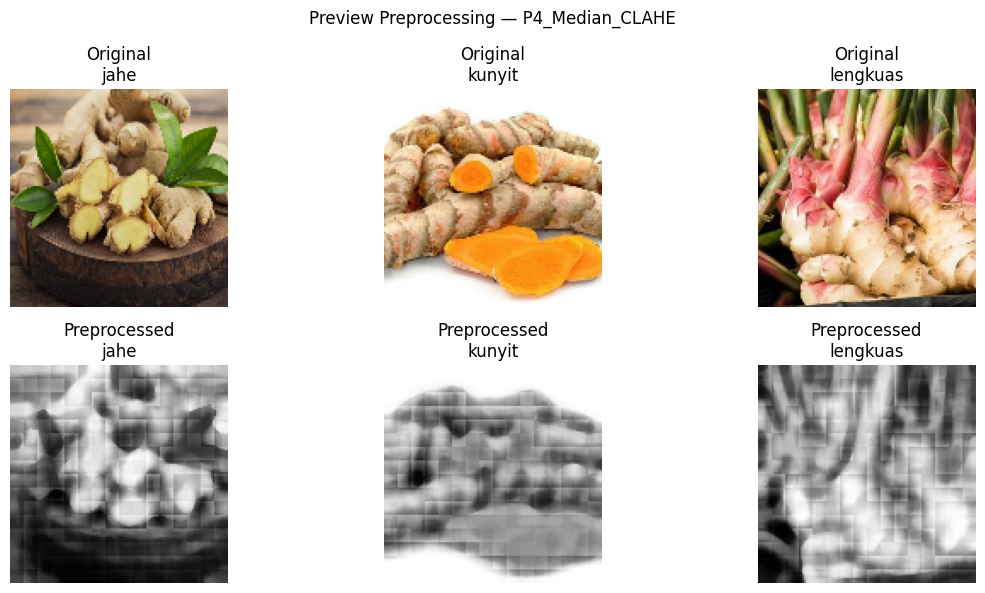

In [24]:
# Cell 4 — Load & Preview
images, labels = load_images()
preview_preprocessing(images, labels, preprocess, EXP_NAME)

Pada Cell 4, dataset citra dan labelnya dimuat menggunakan fungsi `load_images()`, kemudian disimpan ke dalam variabel `images` dan `labels`. Setelah data berhasil dimuat, fungsi `preview_preprocessing()` digunakan untuk menampilkan perbandingan antara citra asli dan citra yang telah melalui tahapan prapemrosesan yang didefinisikan pada fungsi `preprocess()`. Parameter `EXP_NAME` juga disertakan agar hasil visualisasi atau penyimpanan preview dapat dikaitkan dengan eksperimen **P4_Median_CLAHE**. Tahap ini berfungsi sebagai proses verifikasi awal untuk memastikan bahwa resize, konversi grayscale, median blur, dan CLAHE telah diterapkan dengan benar serta menghasilkan kualitas citra yang sesuai sebelum dilanjutkan ke tahap ekstraksi fitur dan pelatihan model klasifikasi.

In [25]:
# Cell 5 — Ekstraksi Fitur GLCM
X = np.array([extract_glcm_features(preprocess(img.copy())) for img in images])
le = LabelEncoder()
y = le.fit_transform(labels)

print(f'Shape fitur: {X.shape}')
print(f'Kelas: {le.classes_}')

os.makedirs('output', exist_ok=True)
df_feat = pd.DataFrame(X, columns=[f'f{i}' for i in range(X.shape[1])])
df_feat['label'] = labels
df_feat.to_csv(f'output/fitur_{EXP_NAME}.csv', index=False)
print(f'Fitur disimpan ke output/fitur_{EXP_NAME}.csv')

Shape fitur: (630, 24)
Kelas: ['jahe' 'kunyit' 'lengkuas']
Fitur disimpan ke output/fitur_P4_Median_CLAHE.csv


Pada Cell 5, dilakukan proses **ekstraksi fitur tekstur menggunakan GLCM (Gray Level Co-occurrence Matrix)** pada seluruh citra yang telah melalui tahapan prapemrosesan. Setiap citra diproses dengan fungsi `preprocess()`, kemudian fitur GLCM diekstraksi menggunakan `extract_glcm_features()` dan disimpan dalam array `X` sebagai data fitur untuk proses klasifikasi. Selanjutnya, label kelas pada variabel `labels` diubah menjadi format numerik menggunakan `LabelEncoder` dan disimpan pada variabel `y`, karena algoritma machine learning memerlukan label dalam bentuk angka. Kode kemudian menampilkan ukuran matriks fitur (`X.shape`) dan daftar kelas yang terdeteksi (`le.classes_`) sebagai informasi validasi data. Setelah itu, direktori `output` dibuat jika belum tersedia, lalu seluruh fitur beserta label aslinya disimpan ke dalam file CSV bernama `fitur_P4_Median_CLAHE.csv`. Penyimpanan fitur ini bertujuan untuk memudahkan analisis lebih lanjut, dokumentasi hasil ekstraksi, serta penggunaan ulang data fitur tanpa perlu mengulangi proses ekstraksi dari awal.

In [26]:
# Cell baru — tambahkan antara Cell 5 dan Cell 6
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit HANYA dari train
X_test = scaler.transform(X_test)        # apply ke test (no fit)

Pada cell ini dilakukan proses **pembagian data dan normalisasi fitur** sebelum pelatihan model klasifikasi. Dataset fitur `X` dan label `y` dibagi menjadi **data latih (80%)** dan **data uji (20%)** menggunakan `train_test_split()`, dengan `random_state=42` agar hasil pembagian konsisten pada setiap percobaan serta `stratify=y` untuk menjaga proporsi setiap kelas tetap seimbang pada data latih dan data uji. Setelah itu, diterapkan **StandardScaler** untuk melakukan standarisasi fitur sehingga setiap fitur memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1. Proses `fit_transform()` dilakukan hanya pada data latih (`X_train`) untuk menghitung parameter normalisasi, sedangkan data uji (`X_test`) hanya dikenai `transform()` menggunakan parameter yang diperoleh dari data latih. Pendekatan ini penting untuk mencegah **data leakage**, yaitu kondisi ketika informasi dari data uji secara tidak sengaja digunakan selama proses pelatihan, sehingga evaluasi model menjadi lebih valid dan mencerminkan performa sebenarnya pada data yang belum pernah dilihat sebelumnya.

Train: 504 | Test: 126
P4_Median_CLAHE | KNN → Train Akurasi: 60.91%
P4_Median_CLAHE | KNN → 46.83%
              precision    recall  f1-score   support

        jahe       0.49      0.62      0.55        42
      kunyit       0.47      0.52      0.49        42
    lengkuas       0.42      0.26      0.32        42

    accuracy                           0.47       126
   macro avg       0.46      0.47      0.46       126
weighted avg       0.46      0.47      0.46       126



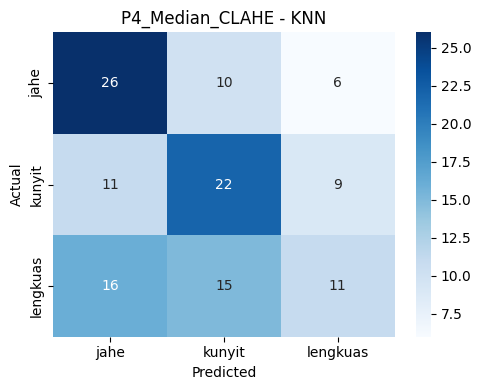

P4_Median_CLAHE | SVM → Train Akurasi: 45.04%
P4_Median_CLAHE | SVM → 50.00%
              precision    recall  f1-score   support

        jahe       0.57      0.60      0.58        42
      kunyit       0.48      0.57      0.52        42
    lengkuas       0.44      0.33      0.38        42

    accuracy                           0.50       126
   macro avg       0.50      0.50      0.49       126
weighted avg       0.50      0.50      0.49       126



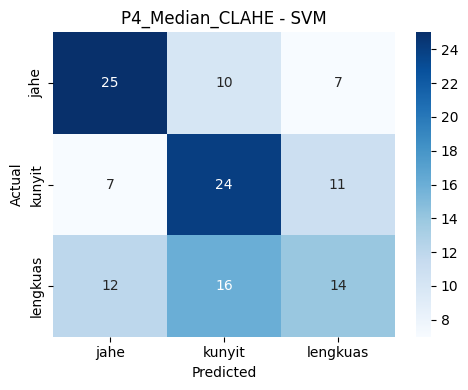

P4_Median_CLAHE | RF → Train Akurasi: 100.00%
P4_Median_CLAHE | RF → 53.17%
              precision    recall  f1-score   support

        jahe       0.60      0.62      0.61        42
      kunyit       0.51      0.52      0.52        42
    lengkuas       0.47      0.45      0.46        42

    accuracy                           0.53       126
   macro avg       0.53      0.53      0.53       126
weighted avg       0.53      0.53      0.53       126



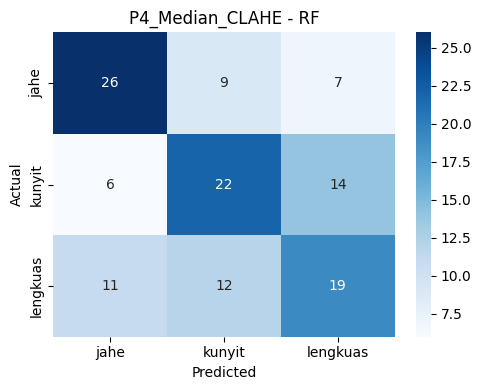


Hasil disimpan ke output/hasil_P4_Median_CLAHE.csv
        Eksperimen Model  Akurasi  Train_Akurasi
0  P4_Median_CLAHE   KNN    46.83          60.91
1  P4_Median_CLAHE   SVM    50.00          45.04
2  P4_Median_CLAHE    RF    53.17         100.00


In [27]:
# Cell 6 — Training & Evaluasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42),
    'RF':  RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []
for model_name, model in models.items():
    model.fit(X_train, y_train)

    # Akurasi train (cek overfitting)
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    print(f'{EXP_NAME} | {model_name} → Train Akurasi: {train_acc*100:.2f}%')

    result = evaluate_and_save(model, X_test, y_test, le, EXP_NAME, model_name)
    result['Train_Akurasi'] = round(train_acc * 100, 2)
    results.append(result)

df_results = pd.DataFrame(results)
df_results.to_csv(f'output/hasil_{EXP_NAME}.csv', index=False)
print(f'\nHasil disimpan ke output/hasil_{EXP_NAME}.csv')
print(df_results)

Pada Cell 6, dilakukan proses **pelatihan dan evaluasi model klasifikasi** menggunakan data yang telah dibagi dan dinormalisasi pada cell sebelumnya. Jumlah data latih dan data uji terlebih dahulu ditampilkan untuk memastikan proses pembagian data berjalan dengan benar. Selanjutnya, tiga algoritma klasifikasi didefinisikan dalam dictionary `models`, yaitu **K-Nearest Neighbor (KNN)** dengan 5 tetangga terdekat, **Support Vector Machine (SVM)** dengan kernel RBF, dan **Random Forest (RF)** dengan 100 pohon keputusan. Melalui perulangan, setiap model dilatih menggunakan data latih (`X_train`, `y_train`) menggunakan metode `fit()`, kemudian dievaluasi pada data uji (`X_test`, `y_test`) menggunakan fungsi `evaluate_and_save()`. Hasil evaluasi dari masing-masing model disimpan ke dalam list `results`, kemudian dikonversi menjadi DataFrame dan diekspor ke file CSV bernama `hasil_P4_Median_CLAHE.csv` pada folder `output`. Tahap ini bertujuan untuk membandingkan performa ketiga algoritma dalam mengklasifikasikan citra berdasarkan fitur tekstur GLCM yang telah diekstraksi, sehingga dapat diketahui model yang memberikan hasil terbaik pada eksperimen yang dilakukan.